# Introduction 

## Purpose
This notebook reproduces the main experiments and validation results reported in the paper using the **Iberian day-ahead market simulator**. It runs the simulator on real OMIE inputs.

The notebook is organized around:
- **Daily backtesting over a date range** (validation against observed prices and cross-border transmissions).
- **Two alternative model configurations** regarding the France coupling/exchange treatment.
- **A counterfactual case study** (wind volume sensitivity) to illustrate “what-if” analysis.

## What you will get out of this notebook
For each simulated day, the notebook computes and stores:
- **Clearing prices** for ES and PT (and their errors vs. observed prices, e.g., MAE).
- **Spain–Portugal transmissions** (and their error vs. observed transmissions, e.g., MAE).
- Diagnostics from the clearing process (e.g., successful iterations, objective value, MIC/paradox/block-bid related counters).

Depending on your configuration, results are:
- Logged to **Weights & Biases** (W&B), or
- Saved locally as per-day `*.pkl` summaries in a `data/experiment_results_...` folder.

## Before you run (important)
### 1) Working directory / paths
This notebook uses relative paths like `data/DET/DET_YYYYMMDD.1` and `data/price_france.parquet`.

To make those paths resolve correctly, run Jupyter **from the `notebooks/` directory**. If you run Jupyter from the repository root, you may need to adapt the paths (or change your working directory).

### 2) Install the package

```bash
pip install iberian-day-ahead-market-simulator .
```

### 3) Solver requirement

The simulator is built on Pyomo and requires a MILP solver (recommended: **Gurobi**). Ensure your solver is installed and available in your environment. Solver choice can affect runtime and (in edge cases) feasibility/convergence behavior. Don't forget to install

```bash
pip install gurobipy  # for Gurobi, make sure you have a valid license and the software installed
```

or

```bash
pip install highspy  # for HiGHS
```

### 4) Data availability

The repo includes a small amount of example data, but **full paper replication requires downloading OMIE data for all days in the configured date range**.

See:
- `data/README.md` for the data description and original sources.
- `download_omie_data.ipynb` for helper code to download OMIE datasets (where supported).

This notebook expects (at minimum) the following to exist for the dates you run:
- `data/DET/DET_YYYYMMDD.1`
- `data/CAB/CAB_YYYYMMDD.1`
- `data/capacidad_inter_pbc/capacidad_inter_pbc_YYYYMMDD.1`
- `data/marginalpdbc.parquet` (observed ES/PT clearing prices)
- `data/price_france.parquet` (France day-ahead prices, used by the coupling component)
- `data/LISTA_UNIDADES.XLS` (unit metadata, used in the wind counterfactual)

## How to run
### Step 1 — Set the global configuration
At the top of the notebook, set:
- `START_DATE`, `END_DATE`: the backtesting window.
- `N_JOBS`: parallelism for scenario analysis (reduce if you have fewer cores).
- `ITERATIONS_COUNT`: max iterations for the clearing loop (reduce for quicker trials).
- `IS_WEIGHTS_AND_BIASES_AVAILABLE`: set `False` if you do not want to use W&B.

Tip: do a **quick smoke test** first by setting `START_DATE == END_DATE` to a single day where you know all files exist.

### Step 2 — Run the daily experiment loops
The notebook runs two daily experiment series over the configured date range:
1. **Fixed cross-border exchanges with France** (uses observed France exchange as an input constraint).
2. **Not fixed cross-border exchanges with France** (France exchange is not fixed but modelled as bids).

For each day, the notebook:
- Loads OMIE inputs (DET/CAB/capacity),
- Loads France prices and observed ES/PT prices,
- Runs the simulator,
- Computes error metrics (e.g., MAE),
- Logs/saves a compact per-day summary.

The loops are wrapped in `try/except` so missing data or solver issues for a given day will be reported and the notebook continues with the next date.

### Step 3 — Run the counterfactual scenario (wind sensitivity)
The final section demonstrates a counterfactual analysis for a selected day by scaling wind bid volumes using `VOLUME_MULTIPLIERS` and re-running the clearing. It then plots:
- Bid vs. cleared wind energy per period, and
- Simulated ES/PT clearing prices compared to observed prices for that day.

## Outputs and where to find them
- **If W&B is enabled**: each day is a separate run under the corresponding `PROJECT_NAME`, and the per-day summary metrics are logged.
- **If W&B is disabled**: per-day summaries are saved as:
  - `data/experiment_results_*/experiment_summary_YYYYMMDD.pkl`

Each summary includes date metadata, convergence/iteration diagnostics, and per-period series (prices and transmissions) alongside aggregate error metrics.

## Troubleshooting
- **File not found**: verify you downloaded the required day(s) and that you launched Jupyter from `notebooks/` so `data/...` points to `notebooks/data/...`.
- **Solver errors / slow runs**: reduce `N_JOBS` and/or `ITERATIONS_COUNT`, and confirm your solver is correctly installed/licensed.
- **W&B issues**: set `IS_WEIGHTS_AND_BIASES_AVAILABLE = False` to run fully offline and write local `*.pkl` summaries instead.



# General configuration

In [ ]:
START_DATE = "2025-03-19"
END_DATE = "2025-09-30"

SOLVER = "gurobi"  # "gurobi" or "highs"
N_JOBS = 14  # Number of parallel processes for scenario analysis
ITERATIONS_COUNT = 150  # Number of iterations for the optimization process in each scenario. Adjust based on convergence needs and computational resources.

IS_WEIGHTS_AND_BIASES_AVAILABLE = True  # Set to True if you have Weights & Biases installed and want to log results there.

# Consts, imports, helpers and configurations

In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error

from iberian_day_ahead_market_simulator import (
    run_iberian_day_ahead_market_simulator,
    cols,
    parse_cab_file,
    parse_det_file,
    FRONTIER_MAPPING_REVERSE,
    parse_marginalpdbc_file,
    plot_clearing_prices,
)


if IS_WEIGHTS_AND_BIASES_AVAILABLE:
    import wandb

    wandb.login()

In [ ]:
DET_FILEPATH_PATTERN = "/path_to_your_data/DET/DET_{YYYYMMDD}.1"
CAB_FILEPATH_PATTERN = "/path_to_your_data/CAB/CAB_{YYYYMMDD}.1"
CAPACIDAD_INTER_PBC_FILEPATH_PATTERN = (
    "/path_to_your_data/capacidad_inter_pbc/capacidad_inter_pbc_{YYYYMMDD}.1"
)
PRICE_FRANCE_FILEPATH = "/path_to_your_data/price_france.parquet"
MARGINALPDBC_FILEPATH = "/path_to_your_data/marginalpdbc.parquet"

In [5]:
price_france_df = pd.read_parquet(PRICE_FRANCE_FILEPATH)
marginalpdbc = pd.read_parquet(MARGINALPDBC_FILEPATH)

In [6]:
def get_france_fixed_exchange(date):

    capacidad_inter_pbc = CAPACIDAD_INTER_PBC_FILEPATH_PATTERN.replace(
        "{YYYYMMDD}", date.strftime("%Y%m%d")
    )

    aux_fr = (
        pd.read_csv(
            capacidad_inter_pbc,
            sep=";",
            skiprows=2,
            encoding="latin1",
            decimal=",",
            thousands=".",
            parse_dates=["Fecha"],
            dayfirst=True,
            skipfooter=1,
            engine="python",
        )
        .query(f'Frontera == {FRONTIER_MAPPING_REVERSE["FR"]}')
        .sort_values("Periodo")
    )
    aux_fr["float_france_exchange"] = np.where(
        aux_fr["Ocupación Importación"] != 0,
        aux_fr["Ocupación Importación"],
        aux_fr["Ocupación exportación"],
    )
    return aux_fr.rename(columns={"Periodo": "int_period"}).set_index("int_period")[
        "float_france_exchange"
    ]


def get_real_spain_portugal_transmissions(date):

    capacidad_inter_pbc = CAPACIDAD_INTER_PBC_FILEPATH_PATTERN.replace(
        "{YYYYMMDD}", date.strftime("%Y%m%d")
    )
    capacidad_inter_pbc = pd.read_csv(
        capacidad_inter_pbc,
        sep=";",
        skiprows=2,
        encoding="latin1",
        decimal=",",
        thousands=".",
        parse_dates=["Fecha"],
        dayfirst=True,
        skipfooter=1,
        engine="python",
    )
    frontera_data = capacidad_inter_pbc.query(
        f'Frontera =={FRONTIER_MAPPING_REVERSE["PT"]}'
    ).sort_values("Periodo")
    frontera_data["Transmision_ES_PT"] = np.where(
        frontera_data["Ocupación Importación"] != 0,
        frontera_data["Ocupación Importación"],
        frontera_data["Ocupación exportación"],
    )
    real_spain_portugal_transmissions = frontera_data.set_index("Periodo").sort_index()[
        "Transmision_ES_PT"
    ]
    return real_spain_portugal_transmissions

# Series of experiments 1: Fixed Cross-Border Exchanges with France

In [7]:
PROJECT_NAME = "paper_replication_fixed_cross_border_exchanges_with_france_with_highs"

In [ ]:
date_range = pd.date_range(start=START_DATE, end=END_DATE, freq="D")

# if not IS_WEIGHTS_AND_BIASES_AVAILABLE create a folder inside data to save the results of the experiments as pickle
if not IS_WEIGHTS_AND_BIASES_AVAILABLE:
    RESULTS_FOLDER = "data/experiment_results_fixed_cross_border_exchanges_with_france"
    os.makedirs(RESULTS_FOLDER, exist_ok=True)

# date_range = pd.to_datetime(dates_to_repeat)
for date in date_range:
    try:
        print(f"Processing date: {date.strftime('%Y-%m-%d')}")

        capacidad_inter_pbc = CAPACIDAD_INTER_PBC_FILEPATH_PATTERN.replace(
            "{YYYYMMDD}", date.strftime("%Y%m%d")
        )
        france_fixed_exchange = get_france_fixed_exchange(date)
        det = DET_FILEPATH_PATTERN.replace("{YYYYMMDD}", date.strftime("%Y%m%d"))
        cab = CAB_FILEPATH_PATTERN.replace("{YYYYMMDD}", date.strftime("%Y%m%d"))
        france_day_ahead_prices = price_france_df[
            price_france_df[cols.DATE_SESION] == date
        ]
        marginalpdbc_date = marginalpdbc[marginalpdbc.dat_sesion == date]
        if IS_WEIGHTS_AND_BIASES_AVAILABLE:
            wandb.init(
                project=PROJECT_NAME,
                name=f"clearing-{date.strftime('%Y-%m-%d')}",
                config={
                    "date": str(date),
                    "iterations_count": ITERATIONS_COUNT,
                    "n_jobs": N_JOBS,
                    "spain_as_default_bidding_zone": True,
                },
                reinit=True,
            )

        results = run_iberian_day_ahead_market_simulator(
            det=det,
            cab=cab,
            capacidad_inter_pbc=capacidad_inter_pbc,
            france_day_ahead_prices=france_day_ahead_prices,
            france_fixed_exchange=france_fixed_exchange,
            iterations_count=ITERATIONS_COUNT,
            spain_as_default_bidding_zone=True,
            n_jobs=N_JOBS,
            solver_factory_type=SOLVER,
        )

        clearing_prices = results["clearing_prices"]
        model_iteration_info = results["model_iteration_info"]
        iterations_df = results["iterations_df"]
        calculated_spain_clearing_prices = (
            clearing_prices.query(f'{cols.CAT_BIDDING_ZONE} == "ES"')
            .set_index(f"{cols.INT_PERIOD}")
            .sort_index()["float_cleared_price"]
        )
        calculated_portugal_clearing_prices = (
            clearing_prices.query(f'{cols.CAT_BIDDING_ZONE} == "PT"')
            .set_index(f"{cols.INT_PERIOD}")
            .sort_index()["float_cleared_price"]
        )
        real_spain_clearing_prices = marginalpdbc_date.set_index("period").sort_index()[
            "precio_es"
        ]
        real_portugal_clearing_prices = marginalpdbc_date.set_index(
            "period"
        ).sort_index()["precio_pt"]

        spain_clearing_price_mae = (
            (calculated_spain_clearing_prices - real_spain_clearing_prices).abs().mean()
        )
        spain_clearing_price_mae_rounded = np.round(spain_clearing_price_mae, 2)
        portugal_clearing_price_mae = (
            (calculated_portugal_clearing_prices - real_portugal_clearing_prices)
            .abs()
            .mean()
        )
        portugal_clearing_price_mae_rounded = np.round(portugal_clearing_price_mae, 2)

        # transmissions

        calculated_spain_portugal_transmissions = results[
            "spain_portugal_transmissions"
        ].sort_index()
        real_spain_portugal_transmissions = get_real_spain_portugal_transmissions(date)
        spain_portugal_transmissions_mae = mean_absolute_error(
            real_spain_portugal_transmissions, calculated_spain_portugal_transmissions
        )
        spain_portugal_transmissions_mae = np.round(spain_portugal_transmissions_mae, 2)

        # iterations to success

        matching_index_mask = np.isclose(
            iterations_df["float_objective_value"],
            model_iteration_info.float_objective_value,
            rtol=1e-9,
            atol=1e-12,
        )
        if not matching_index_mask.any():
            successful_iteration_count = None
        else:
            matching_index = iterations_df.index[matching_index_mask][0]
            successful_iteration_count = matching_index + 1

        cleared_det_cab = results["cleared_det_cab"]

        experiment_summary = {
            "date_str": str(date),
            "date": date,
            "iterations_count": ITERATIONS_COUNT,
            "spain_as_default_bidding_zone": True,
            "successful_iteration_count": successful_iteration_count,
            "objective_value": model_iteration_info.float_objective_value,
            "is_expected_income_respected": model_iteration_info.bool_is_expected_income_respected,
            "scos_with_mic_count": model_iteration_info.int_mic_scos_count,
            "bid_blocks_count": model_iteration_info.int_bid_blocks_count,
            "paradox_groups_count": model_iteration_info.int_paradoxal_orders_count,
            "spain_clearing_price_mae": spain_clearing_price_mae_rounded,
            "portugal_clearing_price_mae": portugal_clearing_price_mae_rounded,
            "spain_portugal_transmissions_mae": spain_portugal_transmissions_mae,
            "calculated_spain_portugal_transmissions": calculated_spain_portugal_transmissions.to_dict()[
                "Transmision_ES_PT"
            ],
            "real_spain_portugal_transmissions": real_spain_portugal_transmissions.to_dict(),
            "calculated_spain_clearing_prices": calculated_spain_clearing_prices.to_dict(),
            "calculated_portugal_clearing_prices": calculated_portugal_clearing_prices.to_dict(),
            "real_spain_clearing_prices": real_spain_clearing_prices.to_dict(),
            "real_portugal_clearing_prices": real_portugal_clearing_prices.to_dict(),
        }
        if IS_WEIGHTS_AND_BIASES_AVAILABLE:
            wandb.log(experiment_summary)
            wandb.finish()
        else:
            # save to pickle
            with open(
                os.path.join(
                    RESULTS_FOLDER, f"experiment_summary_{date.strftime('%Y%m%d')}.pkl"
                ),
                "wb",
            ) as f:
                pickle.dump(experiment_summary, f)

    except Exception as e:
        print(f"Error processing date {date.strftime('%Y-%m-%d')}: {e}")
        # print more info about the error
        display(e)
        continue

# Series of experiments 1: Fixed Cross-Border Exchanges with France

In [ ]:
PROJECT_NAME = (
    "paper_replication_not_fixed_cross_border_exchanges_with_france_with_highs"
)

In [ ]:
date_range = pd.date_range(start=START_DATE, end=END_DATE, freq="D")

# if not IS_WEIGHTS_AND_BIASES_AVAILABLE create a folder inside data to save the results of the experiments as pickle
if not IS_WEIGHTS_AND_BIASES_AVAILABLE:
    RESULTS_FOLDER = "data/experiment_results_fixed_cross_border_exchanges_with_france"
    os.makedirs(RESULTS_FOLDER, exist_ok=True)

# date_range = pd.to_datetime(dates_to_repeat)
for date in date_range:
    try:
        print(f"Processing date: {date.strftime('%Y-%m-%d')}")

        capacidad_inter_pbc = CAPACIDAD_INTER_PBC_FILEPATH_PATTERN.replace(
            "{YYYYMMDD}", date.strftime("%Y%m%d")
        )
        france_fixed_exchange = get_france_fixed_exchange(date)
        det = DET_FILEPATH_PATTERN.replace("{YYYYMMDD}", date.strftime("%Y%m%d"))
        cab = CAB_FILEPATH_PATTERN.replace("{YYYYMMDD}", date.strftime("%Y%m%d"))
        france_day_ahead_prices = price_france_df[
            price_france_df[cols.DATE_SESION] == date
        ]
        marginalpdbc_date = marginalpdbc[marginalpdbc.dat_sesion == date]
        if IS_WEIGHTS_AND_BIASES_AVAILABLE:
            wandb.init(
                project=PROJECT_NAME,
                name=f"clearing-{date.strftime('%Y-%m-%d')}",
                config={
                    "date": str(date),
                    "iterations_count": ITERATIONS_COUNT,
                    "n_jobs": N_JOBS,
                    "spain_as_default_bidding_zone": True,
                },
                reinit=True,
            )

        results = run_iberian_day_ahead_market_simulator(
            det=det,
            cab=cab,
            capacidad_inter_pbc=capacidad_inter_pbc,
            france_day_ahead_prices=france_day_ahead_prices,
            iterations_count=ITERATIONS_COUNT,
            spain_as_default_bidding_zone=True,
            n_jobs=N_JOBS,
            solver_factory_type=SOLVER,
        )

        clearing_prices = results["clearing_prices"]
        model_iteration_info = results["model_iteration_info"]
        iterations_df = results["iterations_df"]
        calculated_spain_clearing_prices = (
            clearing_prices.query(f'{cols.CAT_BIDDING_ZONE} == "ES"')
            .set_index(f"{cols.INT_PERIOD}")
            .sort_index()["float_cleared_price"]
        )
        calculated_portugal_clearing_prices = (
            clearing_prices.query(f'{cols.CAT_BIDDING_ZONE} == "PT"')
            .set_index(f"{cols.INT_PERIOD}")
            .sort_index()["float_cleared_price"]
        )
        real_spain_clearing_prices = marginalpdbc_date.set_index("period").sort_index()[
            "precio_es"
        ]
        real_portugal_clearing_prices = marginalpdbc_date.set_index(
            "period"
        ).sort_index()["precio_pt"]

        spain_clearing_price_mae = (
            (calculated_spain_clearing_prices - real_spain_clearing_prices).abs().mean()
        )
        spain_clearing_price_mae_rounded = np.round(spain_clearing_price_mae, 2)
        portugal_clearing_price_mae = (
            (calculated_portugal_clearing_prices - real_portugal_clearing_prices)
            .abs()
            .mean()
        )
        portugal_clearing_price_mae_rounded = np.round(portugal_clearing_price_mae, 2)

        # transmissions

        calculated_spain_portugal_transmissions = results[
            "spain_portugal_transmissions"
        ].sort_index()
        real_spain_portugal_transmissions = get_real_spain_portugal_transmissions(date)
        spain_portugal_transmissions_mae = mean_absolute_error(
            real_spain_portugal_transmissions, calculated_spain_portugal_transmissions
        )
        spain_portugal_transmissions_mae = np.round(spain_portugal_transmissions_mae, 2)

        # iterations to success

        matching_index_mask = np.isclose(
            iterations_df["float_objective_value"],
            model_iteration_info.float_objective_value,
            rtol=1e-9,
            atol=1e-12,
        )
        if not matching_index_mask.any():
            successful_iteration_count = None
        else:
            matching_index = iterations_df.index[matching_index_mask][0]
            successful_iteration_count = matching_index + 1

        cleared_det_cab = results["cleared_det_cab"]

        experiment_summary = {
            "date_str": str(date),
            "date": date,
            "iterations_count": ITERATIONS_COUNT,
            "spain_as_default_bidding_zone": True,
            "successful_iteration_count": successful_iteration_count,
            "objective_value": model_iteration_info.float_objective_value,
            "is_expected_income_respected": model_iteration_info.bool_is_expected_income_respected,
            "scos_with_mic_count": model_iteration_info.int_mic_scos_count,
            "bid_blocks_count": model_iteration_info.int_bid_blocks_count,
            "paradox_groups_count": model_iteration_info.int_paradoxal_orders_count,
            "spain_clearing_price_mae": spain_clearing_price_mae_rounded,
            "portugal_clearing_price_mae": portugal_clearing_price_mae_rounded,
            "spain_portugal_transmissions_mae": spain_portugal_transmissions_mae,
            "calculated_spain_portugal_transmissions": calculated_spain_portugal_transmissions.to_dict()[
                "Transmision_ES_PT"
            ],
            "real_spain_portugal_transmissions": real_spain_portugal_transmissions.to_dict(),
            "calculated_spain_clearing_prices": calculated_spain_clearing_prices.to_dict(),
            "calculated_portugal_clearing_prices": calculated_portugal_clearing_prices.to_dict(),
            "real_spain_clearing_prices": real_spain_clearing_prices.to_dict(),
            "real_portugal_clearing_prices": real_portugal_clearing_prices.to_dict(),
        }
        if IS_WEIGHTS_AND_BIASES_AVAILABLE:
            wandb.log(experiment_summary)
            wandb.finish()
        else:
            # save to pickle
            with open(
                os.path.join(
                    RESULTS_FOLDER, f"experiment_summary_{date.strftime('%Y%m%d')}.pkl"
                ),
                "wb",
            ) as f:
                pickle.dump(experiment_summary, f)

    except Exception as e:
        print(f"Error processing date {date.strftime('%Y-%m-%d')}: {e}")
        # print more info about the error
        display(e)
        continue

# Counterfactual Scenario Example: Analysis of Price Sensitivity to Wind Power Generation

In [ ]:
DET_FILEPATH = f"data/DET/DET_20250621.1"
CAB_FILEPATH = f"data/CAB/CAB_20250621.1"
CAPACIDAD_INTER_PBC_FILEPATH = (
    f"data/capacidad_inter_pbc/capacidad_inter_pbc_20250621.1"
)

cab_df = parse_cab_file(CAB_FILEPATH)

In [ ]:
results = run_iberian_day_ahead_market_simulator(
    det=DET_FILEPATH,
    cab=CAB_FILEPATH,
    capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
    france_day_ahead_prices=france_day_ahead_prices,
    n_jobs=N_JOBS,
    solver_factory_type=SOLVER,
)

cleared_det_cab = results["cleared_det_cab"]

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25


In [ ]:
unidades_list = pd.read_excel("data/LISTA_UNIDADES.XLS", skiprows=3).iloc[:, :7]
unidades_list["TECNOLOGÍA"].sort_values().unique()

TECNOLOGIA_EOLICA = ["RE Mercado Eólica", "RE Mercado Eólica Marina"]

id_unidades_wind_power = unidades_list.query(
    f"TECNOLOGÍA in @TECNOLOGIA_EOLICA"
).copy()["CODIGO"]
id_orders_wind_power = cab_df.query(f"{cols.ID_UNIDAD} in @id_unidades_wind_power")[
    cols.ID_ORDER
].unique()

cleared_det_cab_wind_power = cleared_det_cab.query(
    f"{cols.ID_UNIDAD} in @id_unidades_wind_power"
).copy()

WARNING *** file size (602379) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


Text(0.5, 0, 'Period')

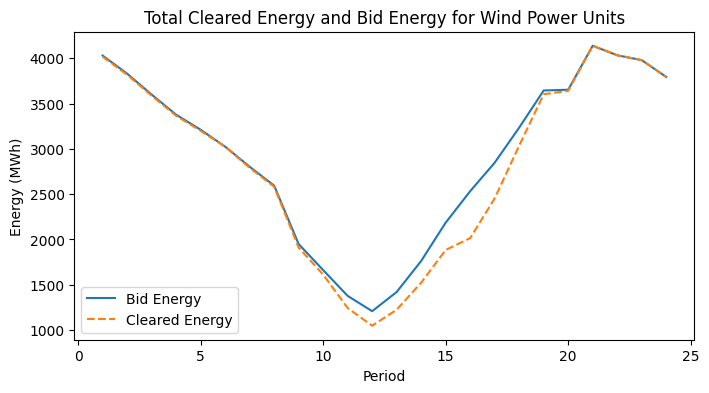

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

wind_power_cleared_power_per_period = (
    cleared_det_cab_wind_power.groupby(cols.INT_PERIOD)[cols.FLOAT_CLEARED_POWER]
    .sum()
    .sort_index()
)
wind_power_bid_power_per_period = (
    cleared_det_cab_wind_power.groupby(cols.INT_PERIOD)[cols.FLOAT_BID_POWER]
    .sum()
    .sort_index()
)

ax.plot(
    wind_power_bid_power_per_period.index,
    wind_power_bid_power_per_period.values,
    label="Bid Energy",
)
ax.plot(
    wind_power_cleared_power_per_period.index,
    wind_power_cleared_power_per_period.values,
    label="Cleared Energy",
    linestyle="dashed",
)
ax.set_title("Total Cleared Energy and Bid Energy for Wind Power Units")
ax.set_ylabel("Energy (MWh)")
ax.legend()

ax.set_xlabel("Period")

## Create scenarios

In [ ]:
VOLUME_MULTIPLIERS = [1, 0.5, 0.75, 1.5, 2.0]

In [ ]:
cab_df = parse_cab_file(CAB_FILEPATH)
det_df = parse_det_file(DET_FILEPATH)
real_clearing_prices = parse_marginalpdbc_file(MARGINALPDBC_FILEPATH)
real_clearing_prices_es = real_clearing_prices.query(
    f"{cols.CAT_BIDDING_ZONE} == 'ES'"
).copy()
real_clearing_prices_pt = real_clearing_prices.query(
    f"{cols.CAT_BIDDING_ZONE} == 'PT'"
).copy()

det_and_cab_dfs_case_5 = {}

for volume_multiplier in VOLUME_MULTIPLIERS:
    cab = cab_df.copy()
    det = det_df.copy()
    cab.loc[cab[cols.ID_ORDER].isin(id_orders_wind_power), cols.FLOAT_MAX_POWER] *= (
        volume_multiplier * 2
    )
    det.loc[
        det[cols.ID_ORDER].isin(id_orders_wind_power), cols.FLOAT_BID_POWER
    ] *= volume_multiplier

    det_and_cab_dfs_case_5[volume_multiplier] = (det, cab)

results_case_5 = {}

for volume_multiplier, (det, cab) in det_and_cab_dfs_case_5.items():
    print(f"Running...")
    result = run_iberian_day_ahead_market_simulator(
        det=det,
        cab=cab,
        capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
        france_day_ahead_prices=france_day_ahead_prices,
        n_jobs=N_JOBS,
        solver_factory_type=SOLVER,
    )
    results_case_5[volume_multiplier] = result

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25
Running...
Running...
Running...
Running...
Running...


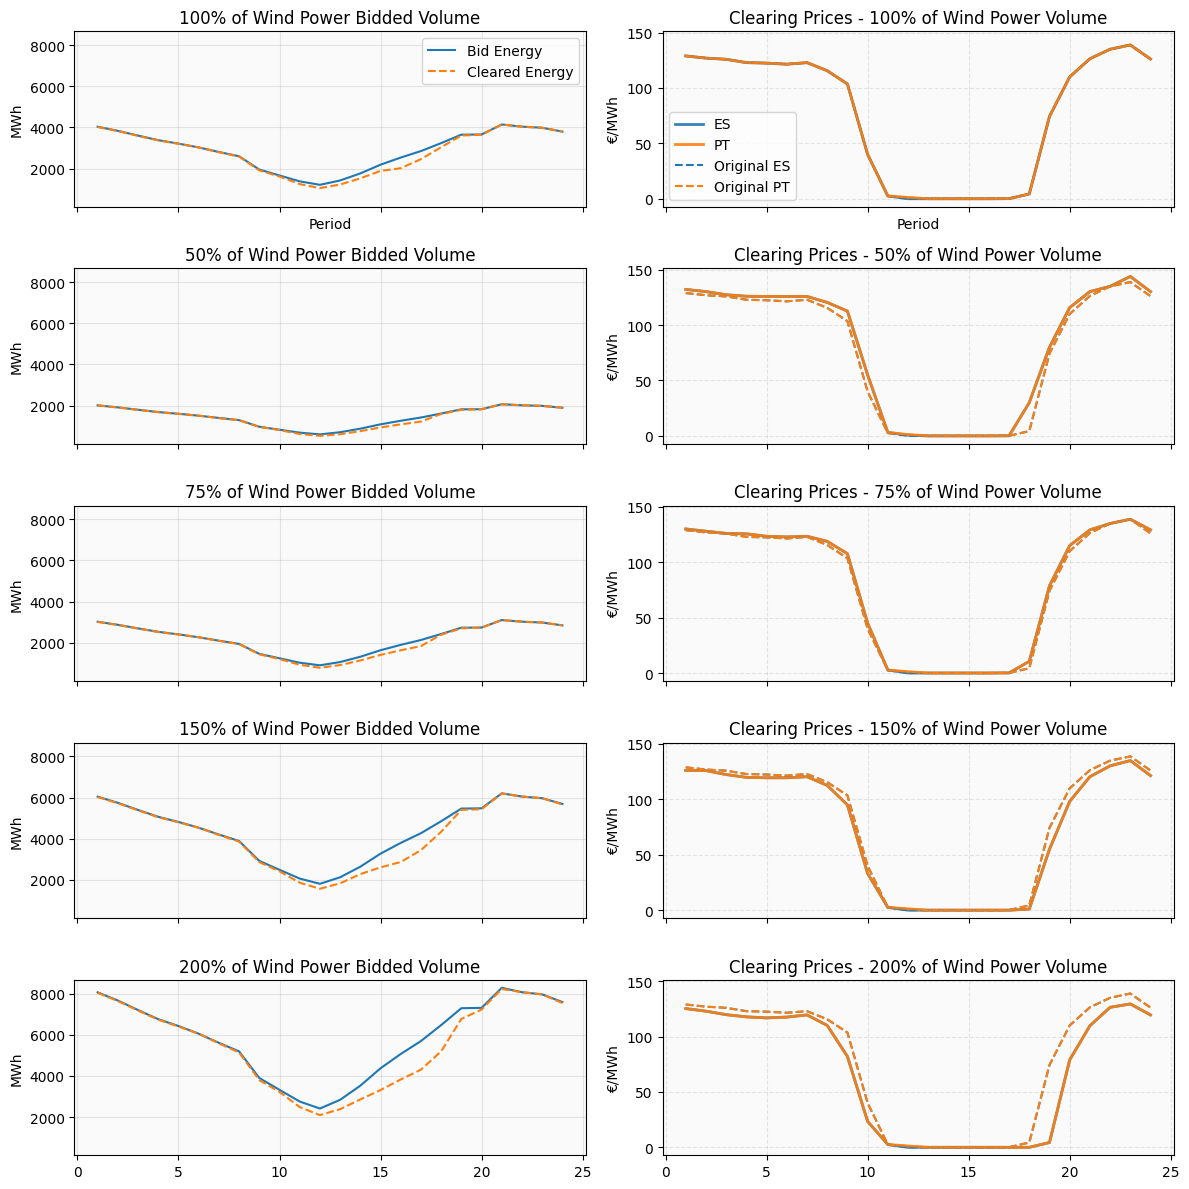

In [ ]:
fig, axes = plt.subplots(
    nrows=len(VOLUME_MULTIPLIERS), ncols=2, figsize=(12, 12), sharex="col", sharey="col"
)

tabpalette = plt.get_cmap("tab10")

for idx, (volume_multiplier, results) in enumerate(results_case_5.items()):
    cleared_det_cab = results["cleared_det_cab"]
    cleared_det_cab_wind_power = cleared_det_cab.query(
        f"{cols.ID_UNIDAD} in @id_unidades_wind_power"
    ).copy()

    wind_power_cleared_power_per_period = (
        cleared_det_cab_wind_power.groupby(cols.INT_PERIOD)[cols.FLOAT_CLEARED_POWER]
        .sum()
        .sort_index()
    )
    wind_power_bid_power_per_period = (
        cleared_det_cab_wind_power.groupby(cols.INT_PERIOD)[cols.FLOAT_BID_POWER]
        .sum()
        .sort_index()
    )

    axes[idx, 0].plot(
        wind_power_bid_power_per_period.index,
        wind_power_bid_power_per_period.values,
        label="Bid Energy",
    )
    axes[idx, 0].plot(
        wind_power_cleared_power_per_period.index,
        wind_power_cleared_power_per_period.values,
        label="Cleared Energy",
        linestyle="dashed",
    )
    axes[idx, 0].set_title(
        f"{volume_multiplier * 100:.0f}% of Wind Power Bidded Volume"
    )
    axes[idx, 0].set_ylabel("MWh")

    plot_clearing_prices(
        results,
        ax=axes[idx, 1],
        title=f"Clearing Prices - {volume_multiplier * 100:.0f}% of Wind Power Volume",
        xlabel=None,
        legend=False,
        ylabel="€/MWh",
        marker="None",
    )
    # plot real clearing prices
    axes[idx, 1].plot(
        real_clearing_prices_es[cols.INT_PERIOD],
        real_clearing_prices_es[cols.FLOAT_CLEARED_PRICE],
        label="Original ES",
        color=tabpalette(0),
        # marker="x",
        markersize=12,
        linestyle="--",
    )
    axes[idx, 1].plot(
        real_clearing_prices_pt[cols.INT_PERIOD],
        real_clearing_prices_pt[cols.FLOAT_CLEARED_PRICE],
        label="Original PT",
        color=tabpalette(1),
        # marker="x",
        markersize=12,
        linestyle="--",
    )

    axes[idx, 0].set_facecolor("#fafafa")
    axes[idx, 1].set_facecolor("#fafafa")
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 1].grid(True, alpha=0.3)

# last_index = len(results_case_5) - 1
axes[0, 1].legend()
axes[0, 0].legend()
axes[0, 0].set_xlabel("Period")
axes[0, 1].set_xlabel("Period")

plt.tight_layout()
plt.show()